## Connect to Google Drive

## Install Libraries

In [23]:
!pip install numpy==1.26.4 ultralytics mediapipe
# opencv-python scikit-learn matplotlib xgboost mediapipe


## Importing Libraries

In [24]:
# Import necessary libraries for the project

import matplotlib.pyplot as plt  # For plotting and visualization
import cv2  # OpenCV for image and video processing
import os  # For interacting with the operating system (file paths, directories)
import numpy as np  # For numerical operations and array handling
from ultralytics import YOLO  # For YOLO pose estimation model
import mediapipe as mp  # For MediaPipe pose estimation models
from sklearn.model_selection import train_test_split  # For splitting data into train/test sets
from sklearn.preprocessing import MinMaxScaler, LabelEncoder  # For feature scaling and label encoding
from sklearn.linear_model import LogisticRegression  # Logistic Regression classifier
from sklearn.svm import SVC  # Support Vector Classifier
from sklearn.ensemble import RandomForestClassifier  # Random Forest classifier
from xgboost import XGBClassifier  # XGBoost classifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix  # Evaluation metrics
import seaborn as sns  # For advanced data visualization (heatmaps, etc.)
import pandas as pd  # For data manipulation and analysis
import joblib  # For saving and loading models and preprocessing objects
from collections import Counter  # For counting occurrences of elements (e.g., predictions)
import shutil  # For high-level file operations (copying, removing directories)
from IPython.display import display, Image  # Import display and Image from IPython.display for displaying images in the notebook.


# Object Detection

In [25]:
!pip install roboflow==1.1.48 --quiet


In [26]:
import os # Get the current working directory
HOME = os.getcwd() # Get the current working directory
print(HOME) # Print the current working directory


/content


In [27]:
from IPython import display  # Import the display module from IPython for clearing outputs and displaying images.
display.clear_output()  # Clear the current output in the Jupyter Notebook cell.

import ultralytics  # Import the ultralytics library, which is used for YOLO model training and inference.
ultralytics.checks()  # Run checks to ensure the ultralytics library and its dependencies are properly installed.

from ultralytics import YOLO  # Import the YOLO class from the ultralytics library for model creation and usage.
from IPython.display import display, Image  # Import display and Image from IPython.display for displaying images in the notebook.


Ultralytics 8.4.66 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 48.2/112.6 GB disk)


In [28]:
!mkdir -p {HOME}/datasets  # Create a directory named 'datasets' inside the current working directory if it doesn't already exist.
%cd {HOME}/datasets  # Change the current working directory to the newly created 'datasets' directory.

from roboflow import Roboflow  # Import the Roboflow class from the roboflow library.

rf = Roboflow(api_key="UGmDlp3rOig59tfYSH9m")  # Initialize the Roboflow object with the provided API key.

project = rf.workspace("alexa-fiverr").project("alexa-tybnf")  # Access the specific project within the specified workspace.

dataset = project.version(1).download("yolov8")  # Download version 3 of the dataset in YOLOv8 format.


[Errno 2] No such file or directory: '/content/datasets # Change the current working directory to the newly created datasets directory.'
/content
loading Roboflow workspace...
loading Roboflow project...


In [29]:
%cd {HOME}
!yolo task=detect mode=train model=yolov8s.pt data={dataset.location}/data.yaml epochs=5 imgsz=800 plots=True
# Run the YOLO command-line interface to train a detection model:
# - task=detect: Specifies the task as object detection.
# - mode=train: Sets the mode to training.
# - model=yolov8s.pt: Specifies the pre-trained YOLOv8s model to use as a starting point.
# - data={dataset.location}/data.yaml: Specifies the path to the dataset configuration file.
# - epochs=5: Sets the number of training epochs to 5.
# - imgsz=800: Sets the image size for training to 800x800 pixels.
# - plots=True: Enables the generation of training plots.


/content
Ultralytics 8.4.66 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Alexa-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=800, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patien

/content


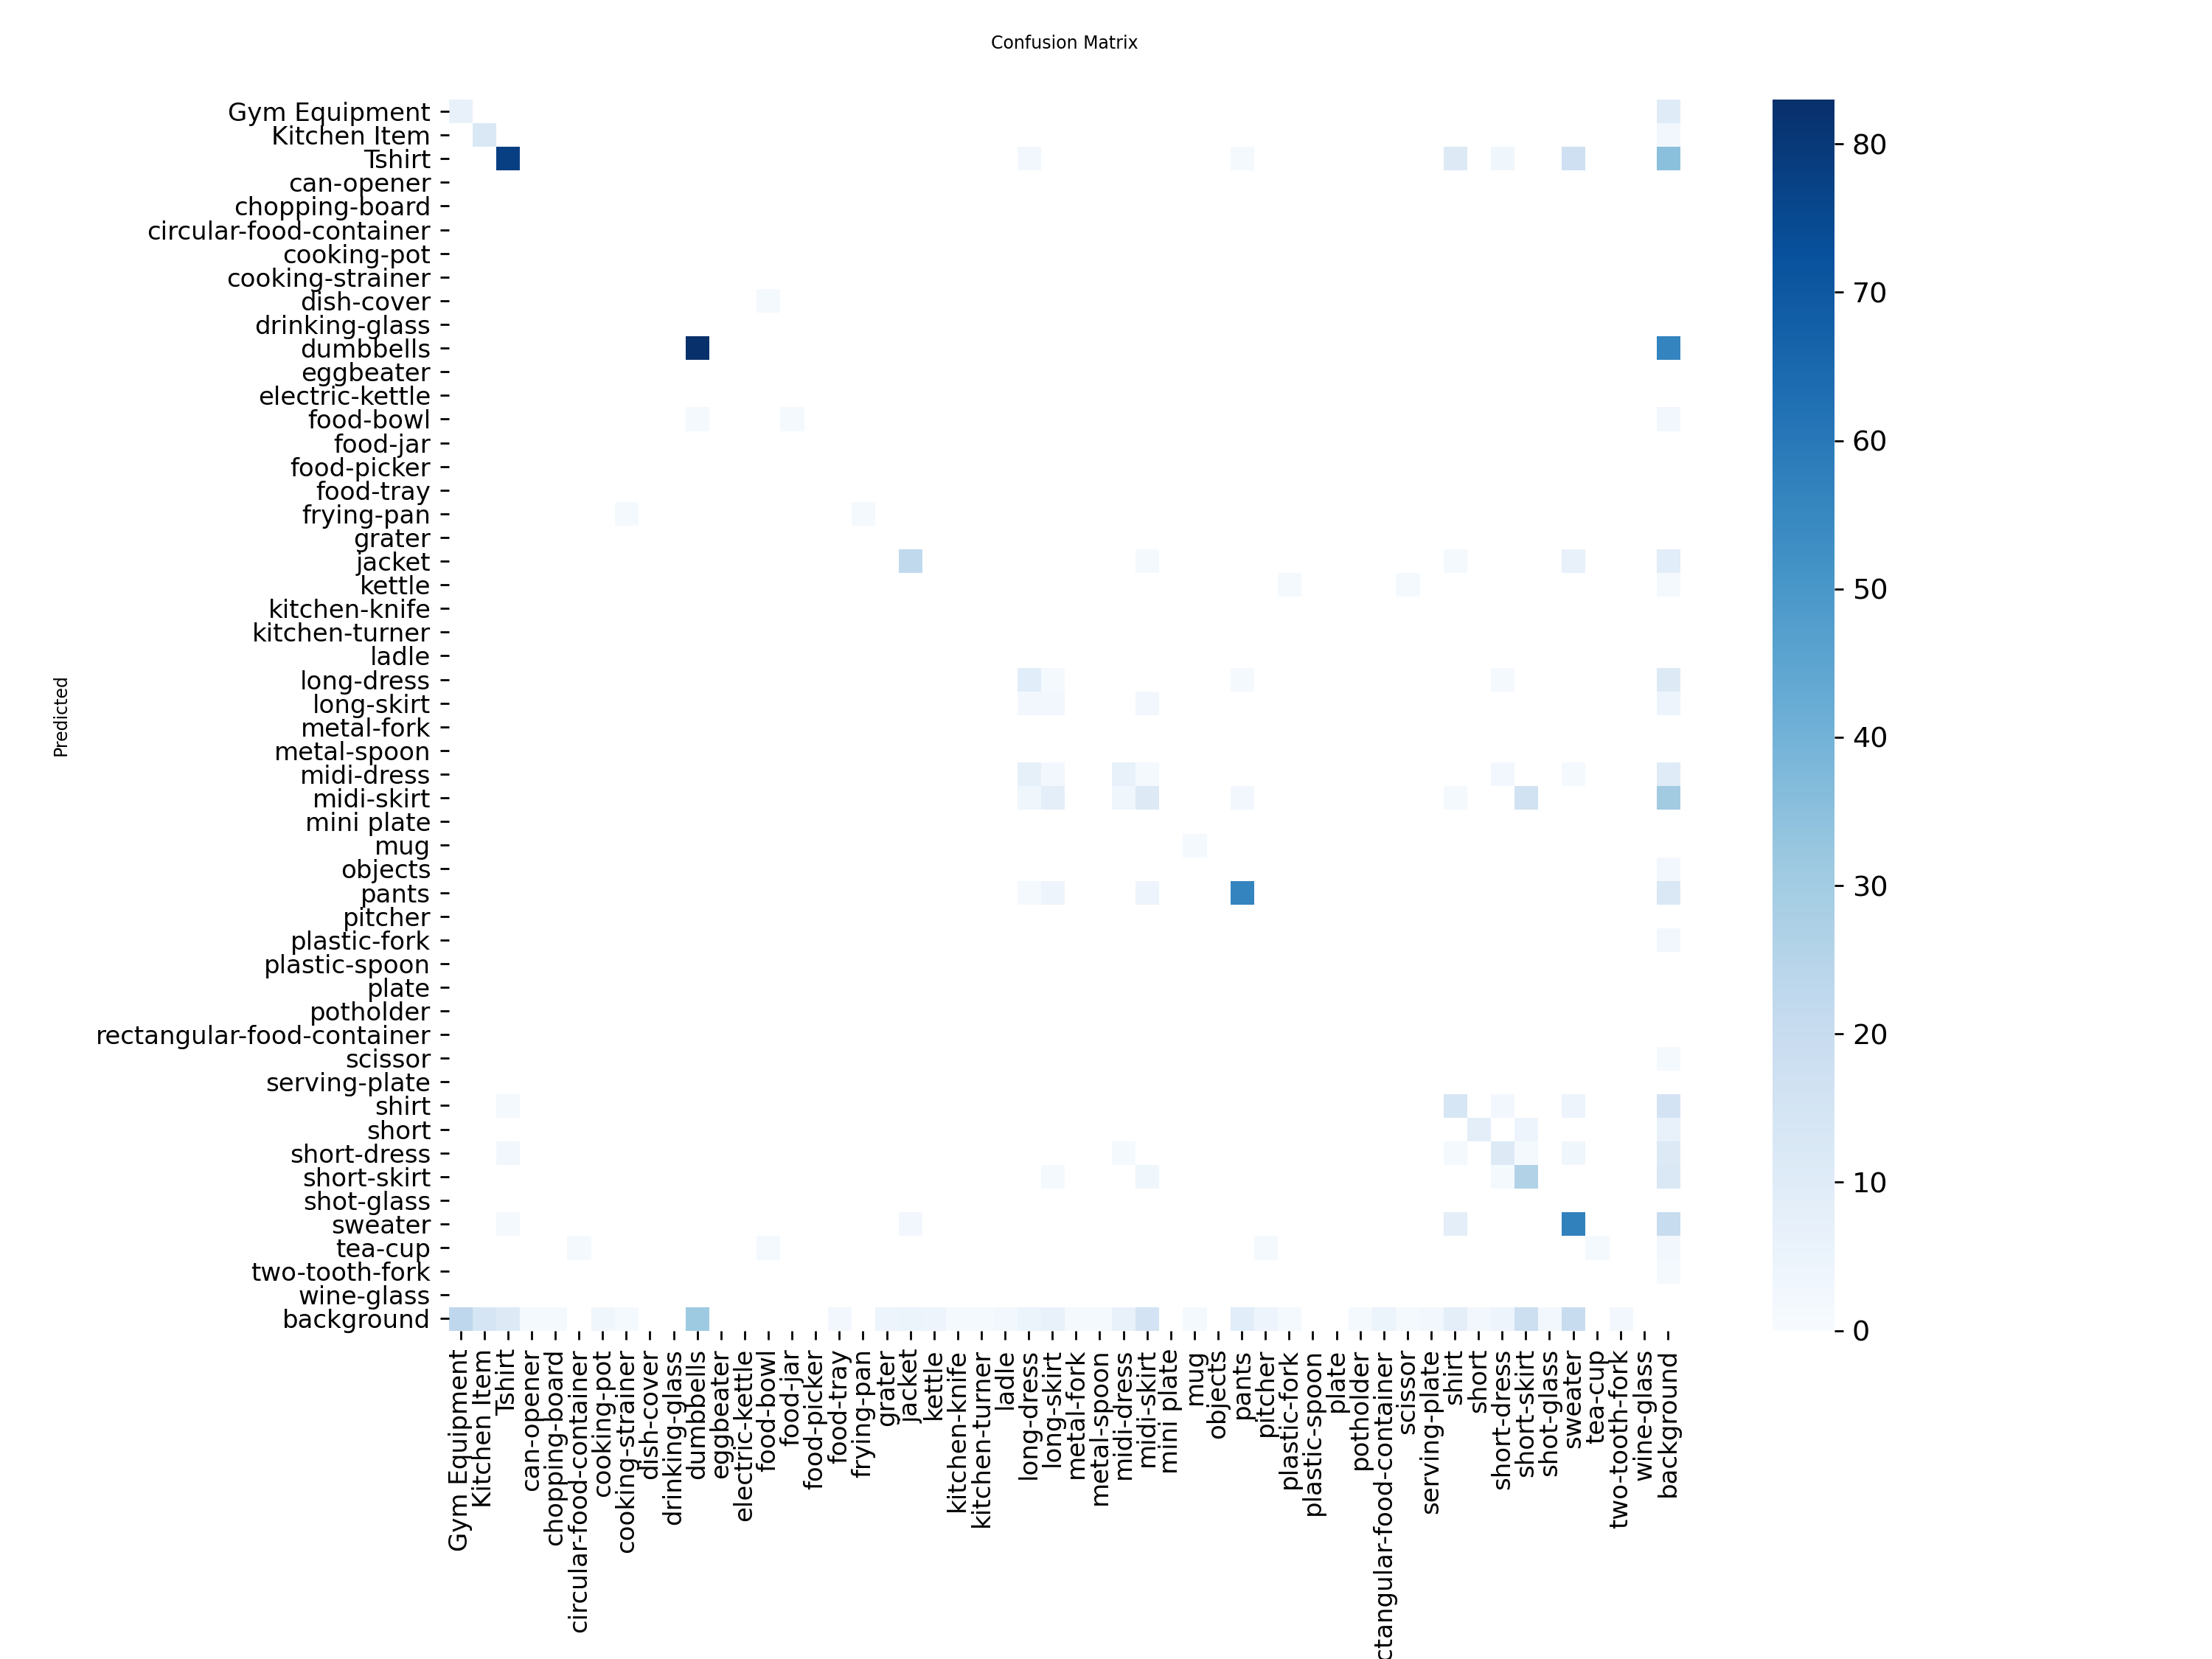

In [30]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train/confusion_matrix.png', width=600)  # Display the confusion matrix image from the specified path with a width of 600 pixels.


/content


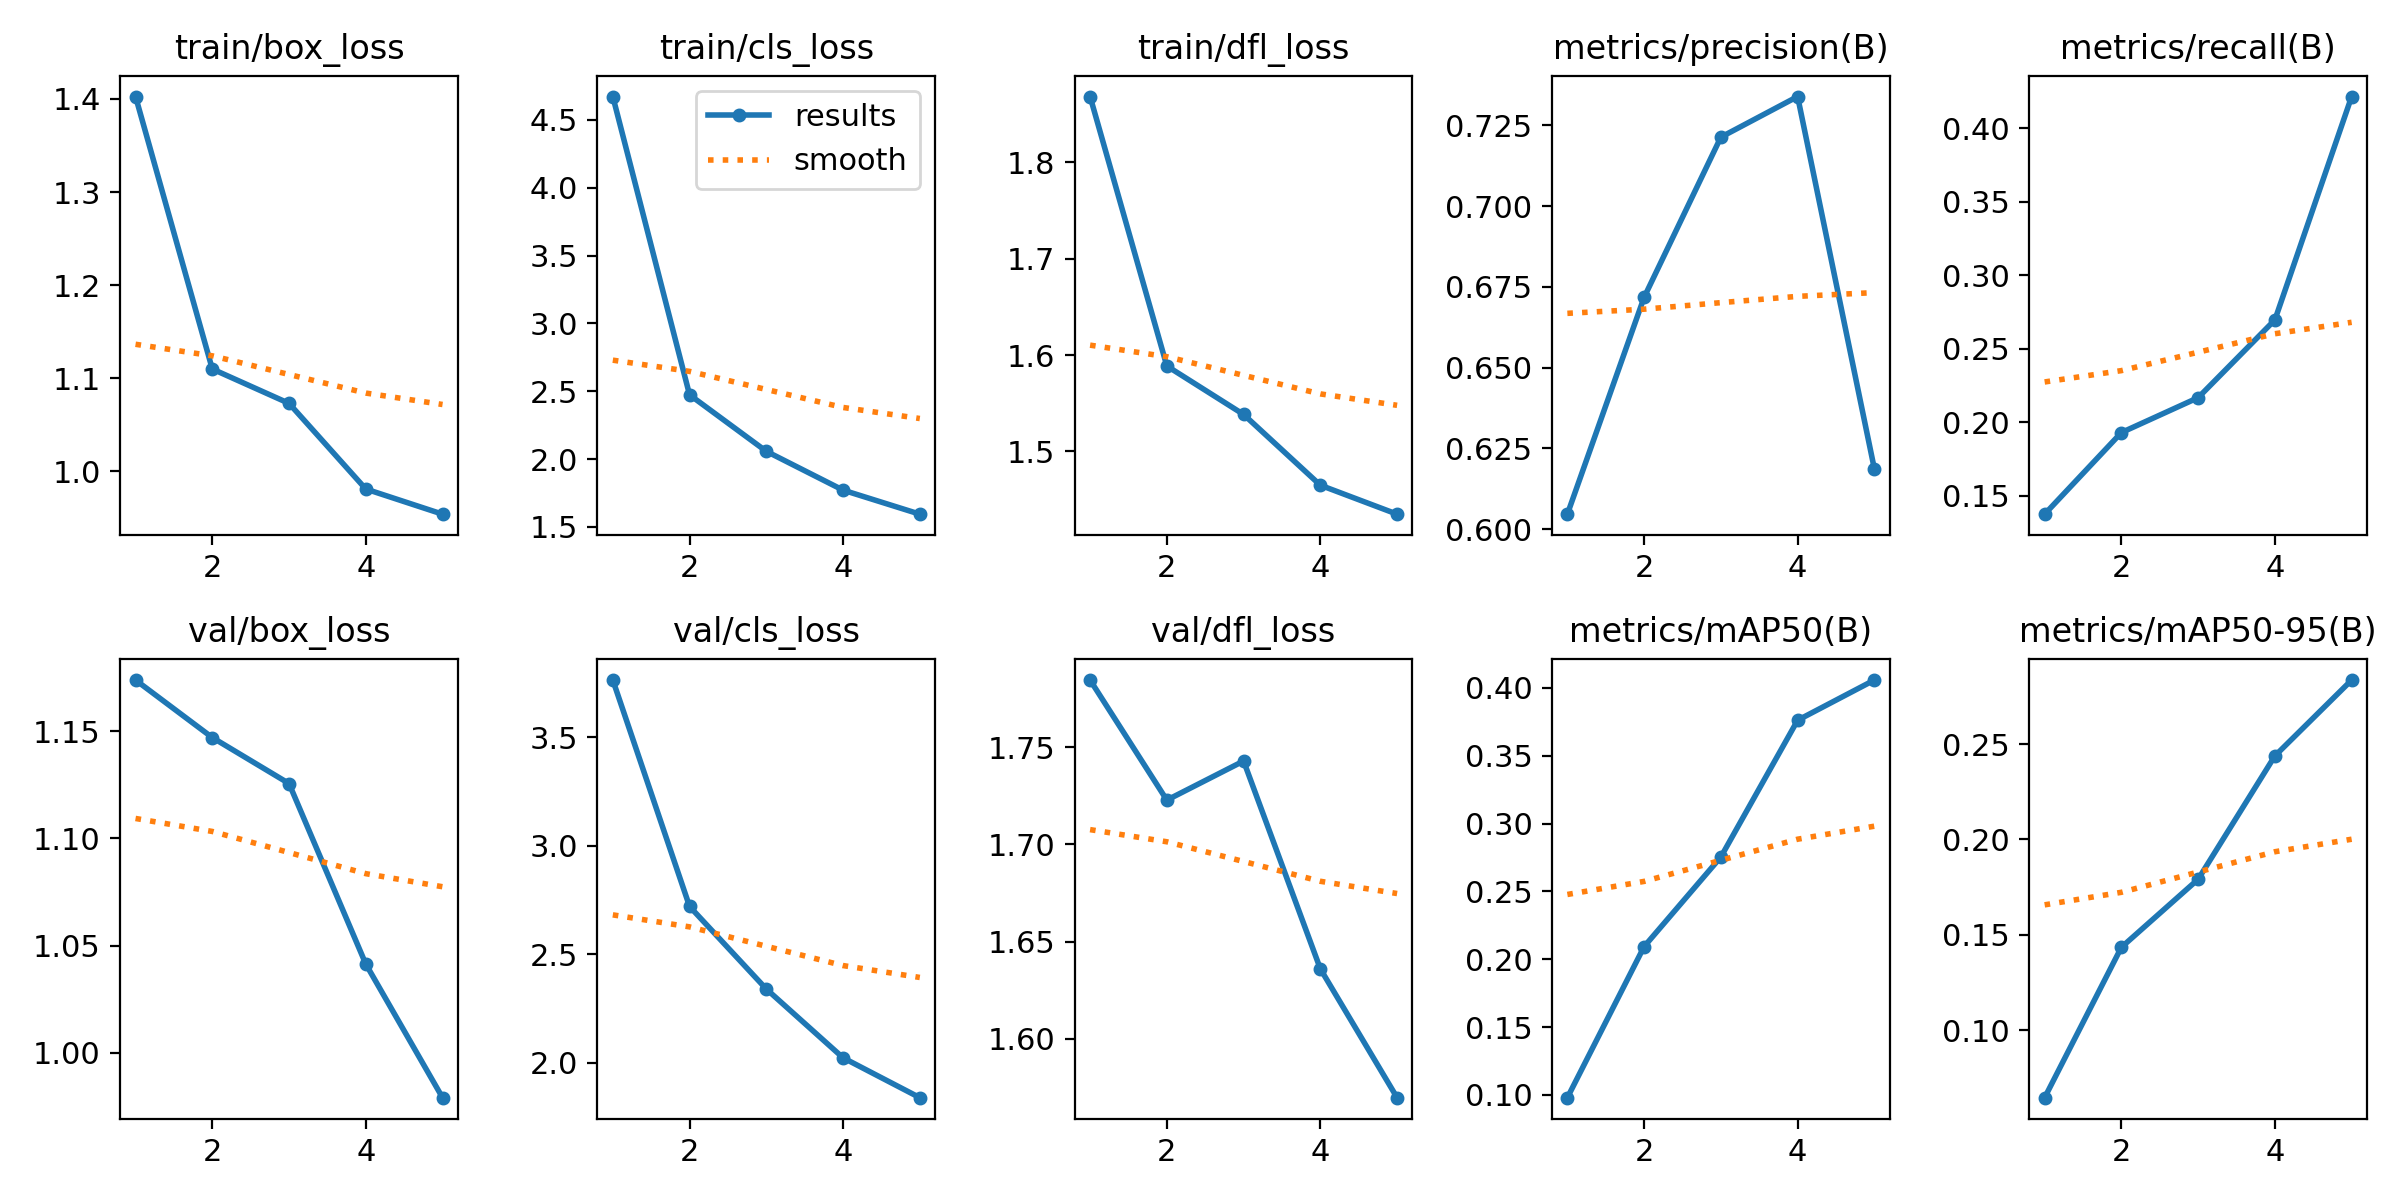

In [31]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train/results.png', width=600)


/content


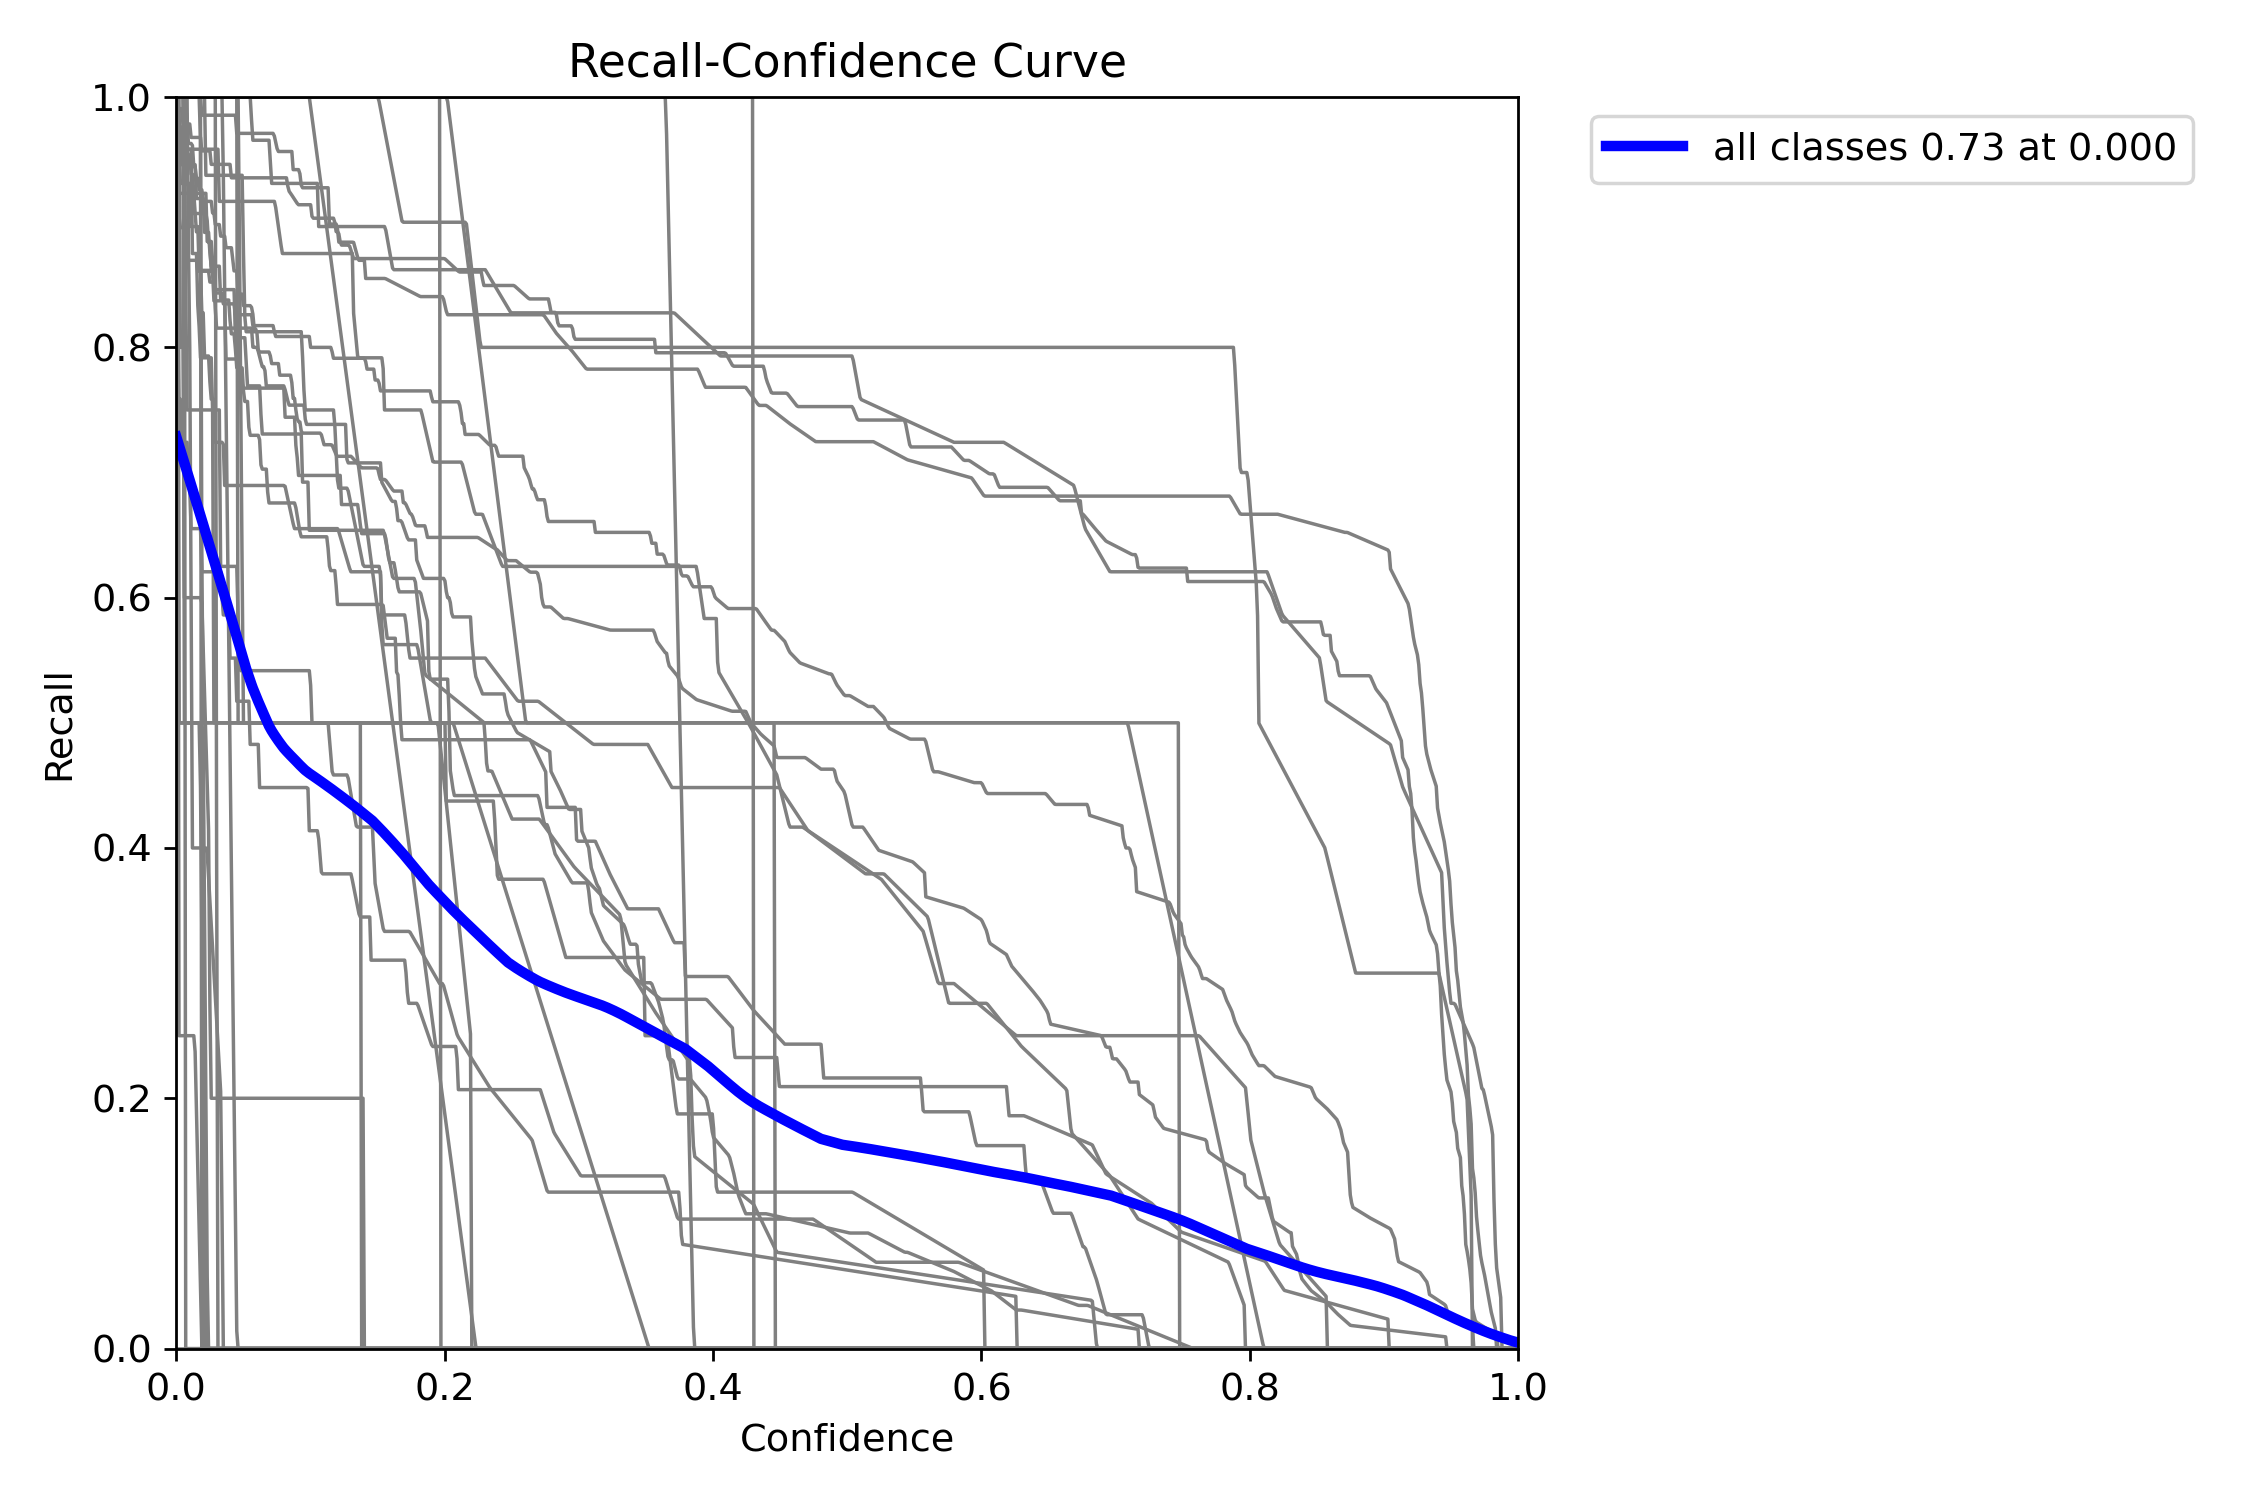

In [32]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train/BoxR_curve.png', width=600)

/content


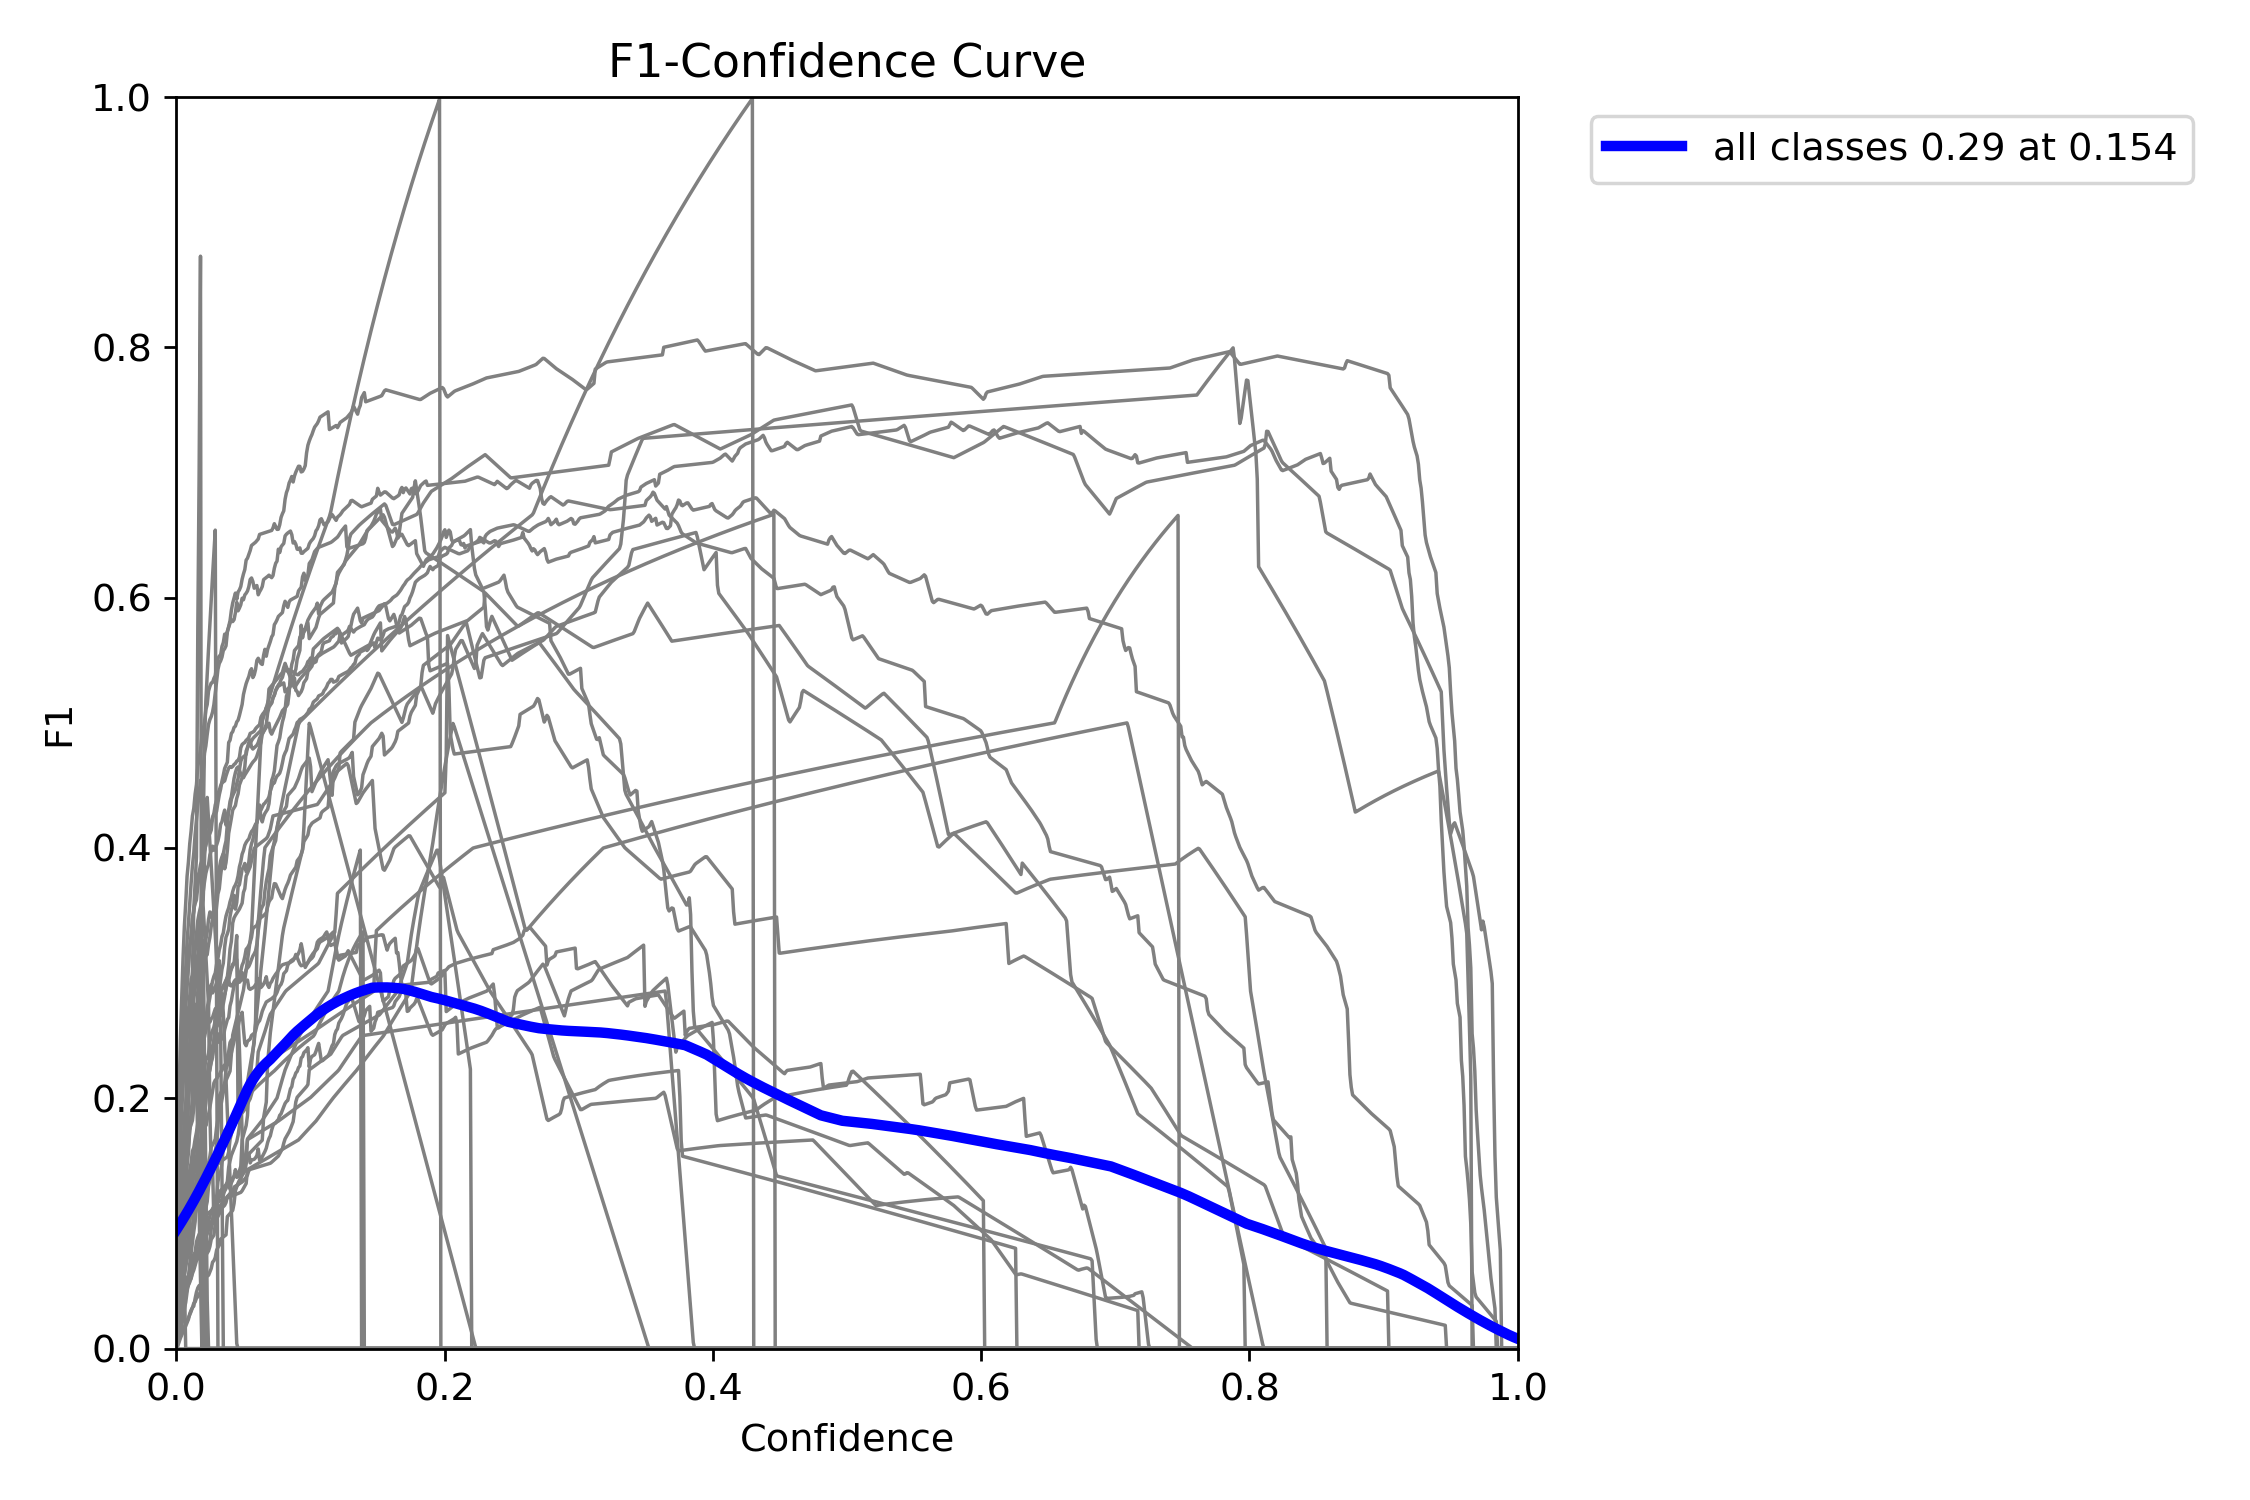

In [33]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train/BoxF1_curve.png', width=600)


/content


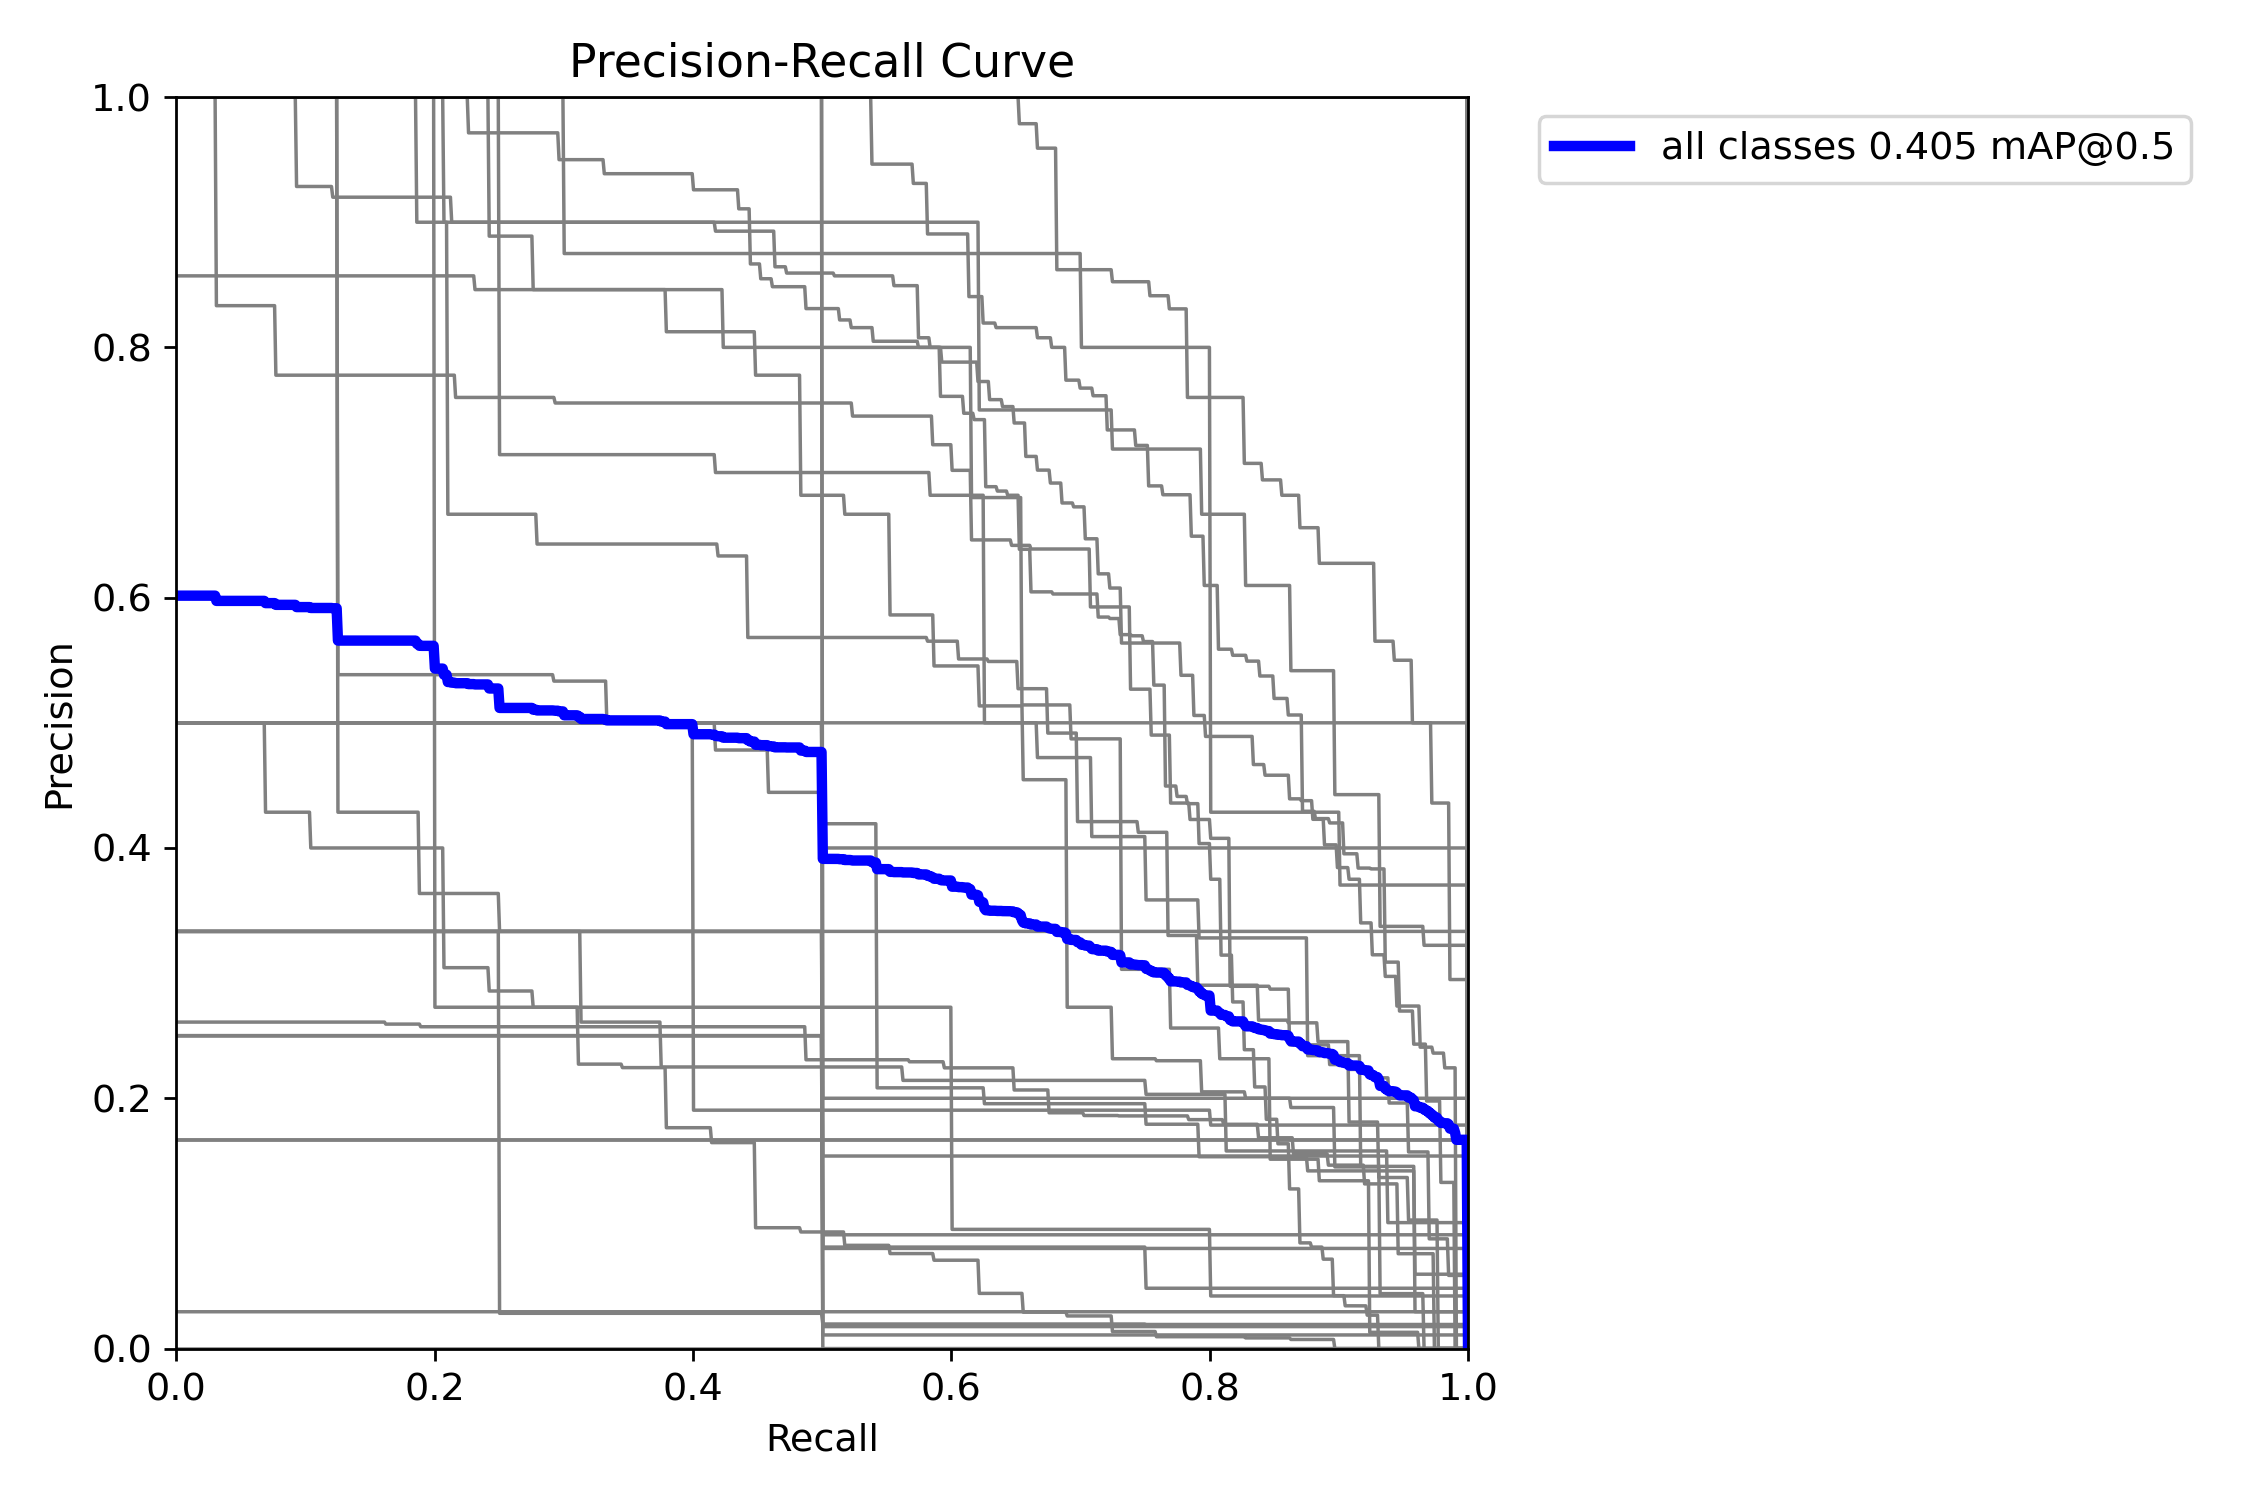

In [34]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train/BoxPR_curve.png', width=600)


/content


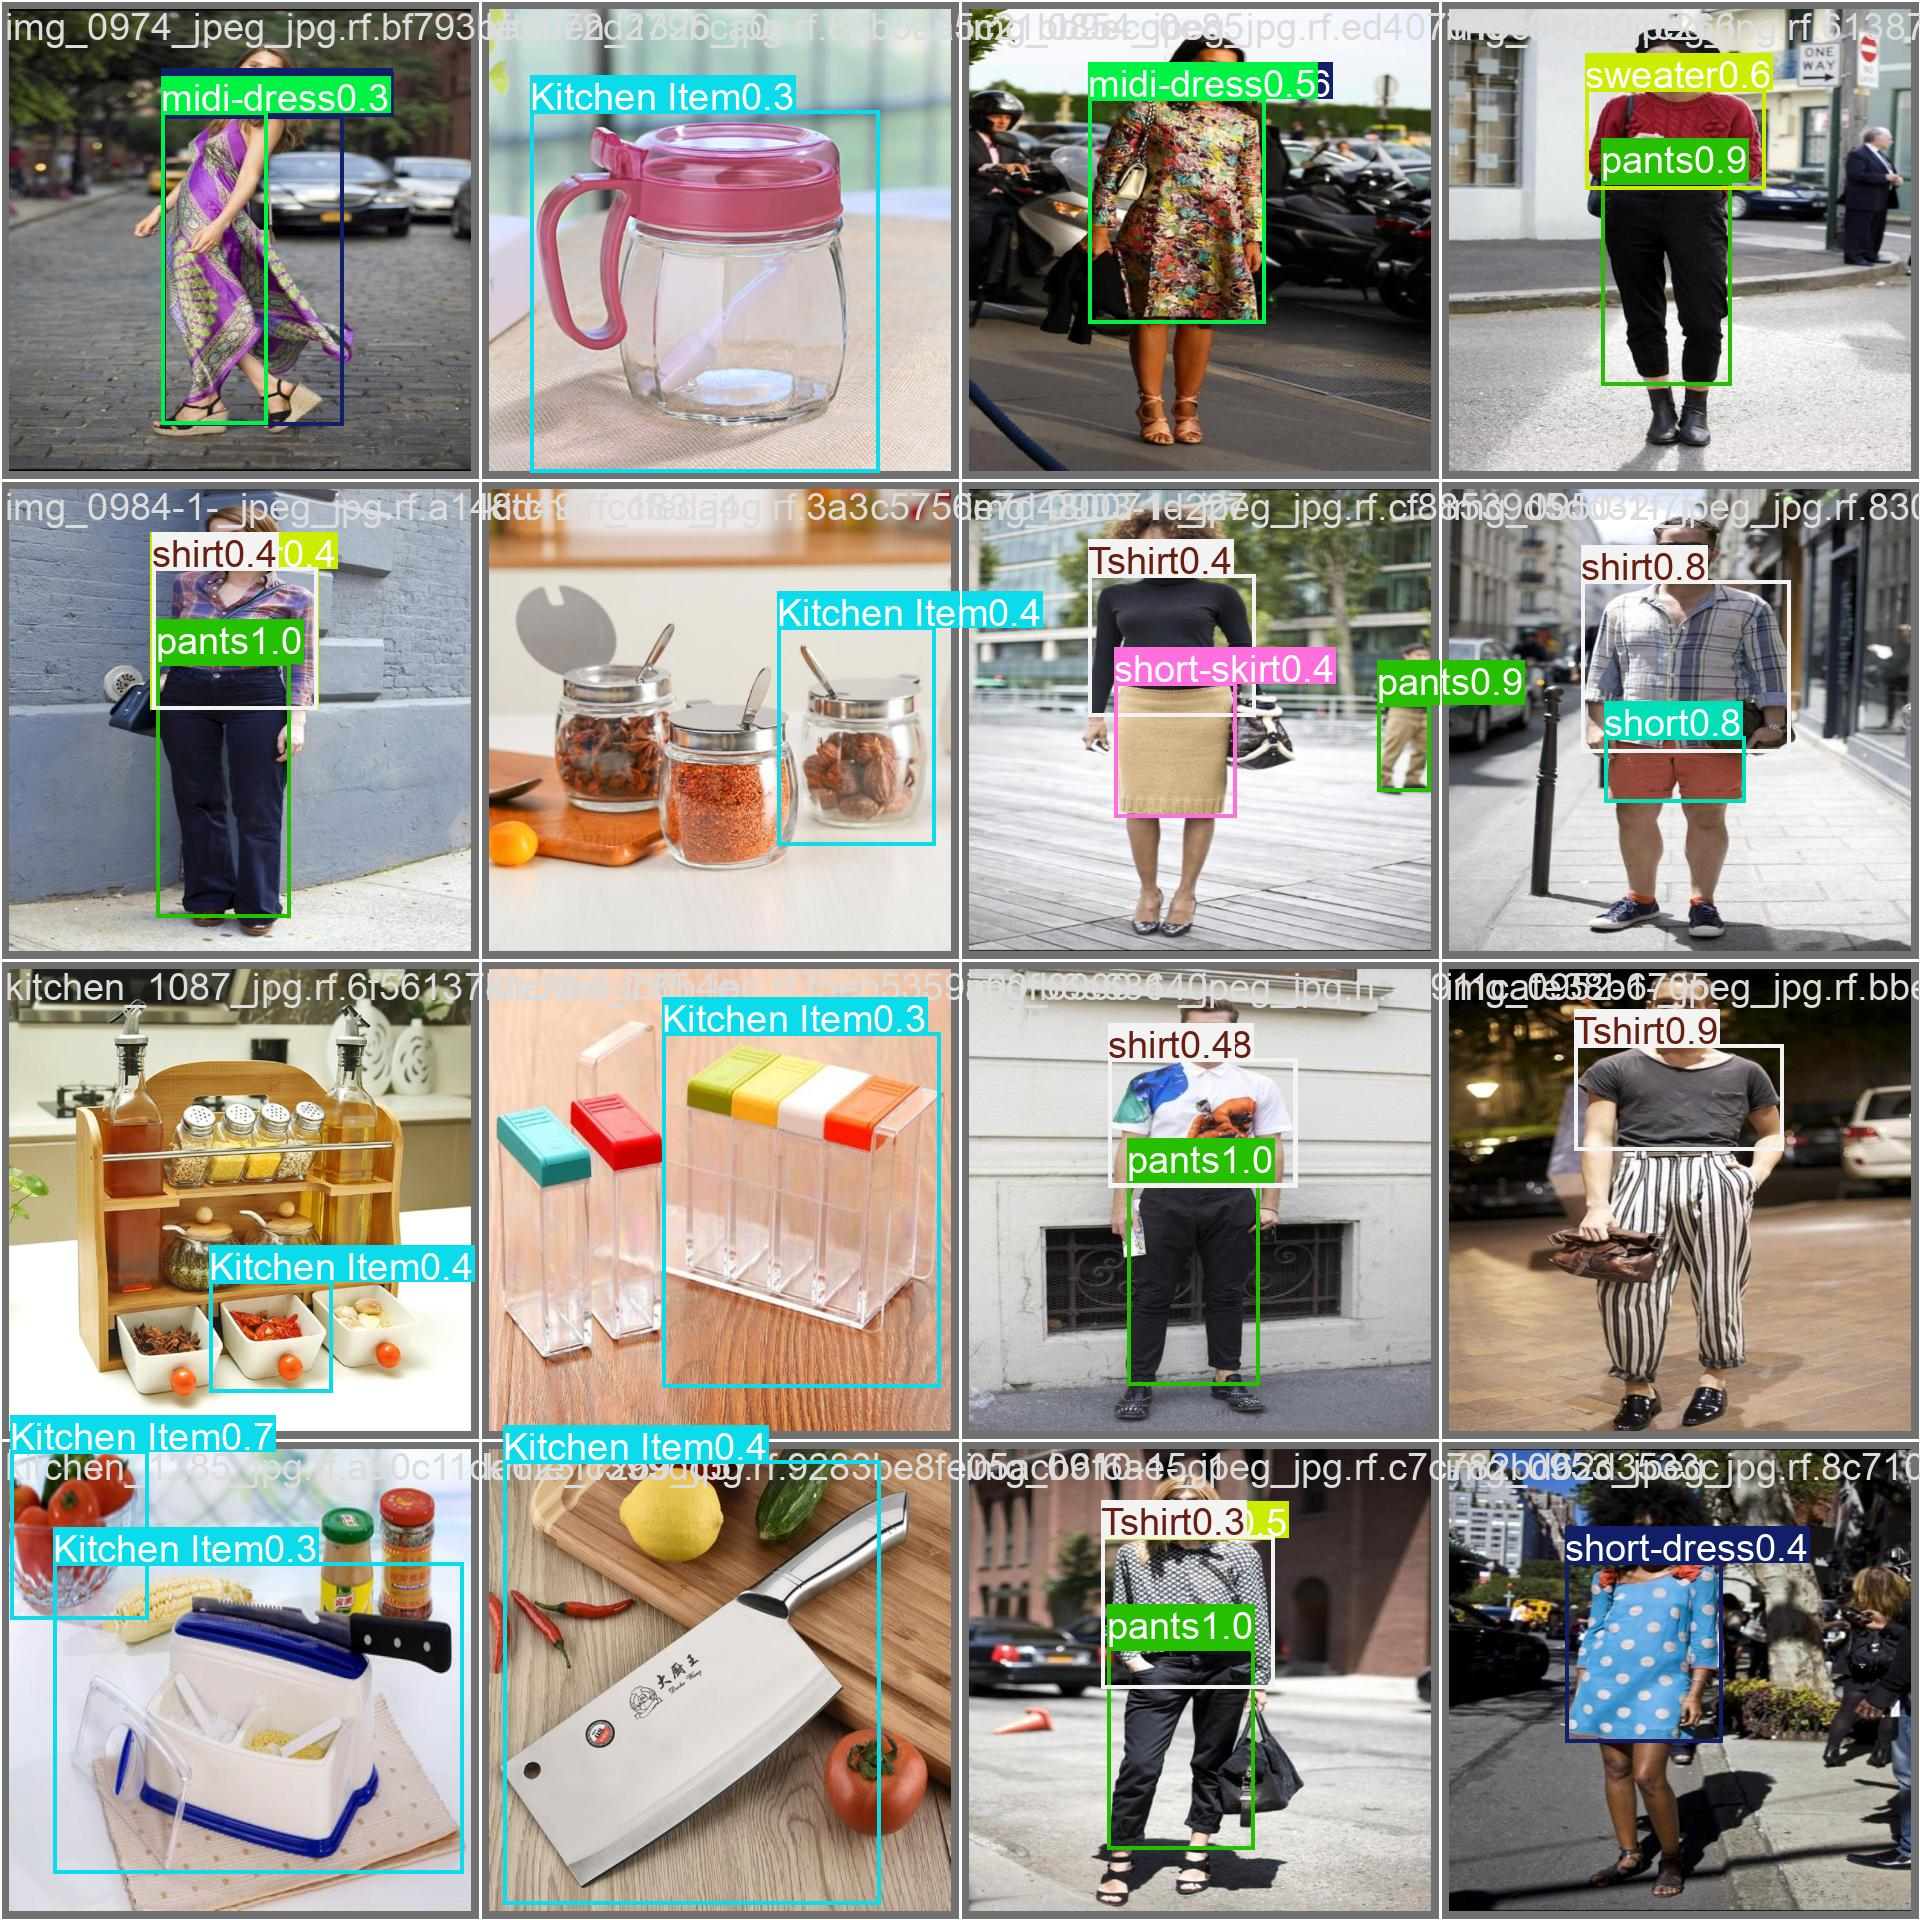

In [35]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train/val_batch0_pred.jpg', width=600)


In [36]:
from ultralytics import YOLO
import os

# Fixed: Added quotes and changed the space to an underscore
video_path = "/content/7502882-hd_1920_1080_30fps (1).mp4"

model = YOLO("/content/runs/detect/train/weights/best.pt")

custom_output_dir = "/content"
output_video_path = os.path.join(custom_output_dir, "result.mp4")

results = model(video_path, save=True, save_dir=custom_output_dir)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/760) /content/7502882-hd_1920_1080_30fps (1).mp4: 480x800 2 pantss, 1 shirt, 16.4ms
video 1/1 (frame 2/760) /content/7502882-hd_1920_1080_30fps (1).mp4: 480x800 2 pantss, 1 shirt, 15.7ms
video 1/1 (frame 3/760) /content/7502882-hd_1920_1080_30fps (1).mp4: 480x800 2 pantss, 1 shirt, 15.7ms
video 1/1 (frame 4/760) /content/7502882-hd_1920_1080_30fps (1).mp4: 480x800 2 pantss, 1 shirt, 15.7ms
video 1/1 (frame 5/760) /content/7502882-hd_19